Iteration 1, loss = 0.85682877
Iteration 2, loss = 0.79265389
Iteration 3, loss = 0.71550007
Iteration 4, loss = 0.67745392
Iteration 5, loss = 0.69228807
Iteration 6, loss = 0.67763857
Iteration 7, loss = 0.69017597
Iteration 8, loss = 0.69502787
Iteration 9, loss = 0.68739874
Iteration 10, loss = 0.70221901
Iteration 11, loss = 0.70253303
Iteration 12, loss = 0.70061816
Iteration 13, loss = 0.69123538
Iteration 14, loss = 0.68516380
Iteration 15, loss = 0.69813279
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


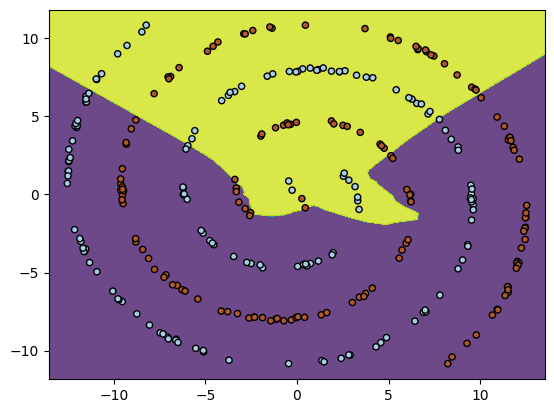

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

def generate_xor_data(n_samples):
    np.random.seed(0)
    X = np.random.randn(n_samples, 2)
    y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0)
    return X, y.astype(int)

def generate_spiral_data(n_samples, noise=0.2):
    n = np.sqrt(np.random.rand(n_samples//2)) * 780 * (2*np.pi)/360
    d1x = -np.cos(n)*n + np.random.rand(n_samples//2) * noise
    d1y = np.sin(n)*n + np.random.rand(n_samples//2) * noise
    return (np.vstack((np.column_stack((d1x, d1y)), np.column_stack((-d1x, -d1y)))), 
            np.hstack((np.zeros(n_samples//2), np.ones(n_samples//2))))

def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    h = 0.02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', s=20, cmap=plt.cm.Paired)
    plt.show()

# Generate XOR data
# X, y = generate_xor_data(300)  # Use generate_spiral_data for the spiral dataset
X, y = generate_spiral_data(300)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create MLP classifier
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=10000, alpha=1e-4,
                    solver='sgd', verbose=10, random_state=1,
                    learning_rate_init=.01)

# Train MLP
mlp.fit(X_train, y_train)

# Plot decision boundary
plot_decision_boundary(X, y, mlp)
